# Numerical Integration



## 1. Motivation

- **The Problem**: Most physical systems do not have analytical solutions (e.g., the period of a pendulum at large amplitudes, or the partition function in thermodynamics).

- **The Objective**: Transform a continuous integral $\int_{a}^{b} f(x) dx$ into a discrete sum $\sum w_i f(x_i)$.


## 2. Fixed-Grid Numerical Integration: Newton-Cotes Methods

### 2.1 The Concept of Newton-Cotes

The fundamental problem in numerical integration is approximating the integral:

$$I = \int_{a}^{b} f(x) \, dx$$

Newton-Cotes formulas are based on a simple strategy:

1. Divide the interval $[a, b]$ into $n$ equal segments of width $h = \frac{b-a}{n}$.

1. Define discrete points (nodes) $x_i = a + ih$ for $i = 0, 1, \dots, n$.

1. Replace the unknown function $f(x)$ with an interpolating polynomial $P_k(x)$ of degree $k$ that passes through these nodes.

1. Integrate the polynomial exactly.

The "order" of the Newton-Cotes method depends on the degree $k$ of the polynomial used for approximation.

### 2.2 The Trapezoidal Rule (Linear Approximation)

#### 2.2.1 Derivation

In the Trapezoidal rule, we approximate $f(x)$ in each sub-interval $[x_i, x_{i+1}]$ **as a straight line (a 1st-degree polynomial)**. Using the Lagrange form of the interpolating polynomial for two points $(x_i, f_i)$ and $(x_{i+1}, f_{i+1})$:

$$P_1(x) = f_i \frac{x - x_{i+1}}{x_i - x_{i+1}} + f_{i+1} \frac{x - x_i}{x_{i+1} - x_i}$$

Substituting $h = x_{i+1} - x_i$:

$$P_1(x) = \frac{f_i}{-h}(x - x_{i+1}) + \frac{f_{i+1}}{h}(x - x_i)$$

Now, we integrate $P_1(x)$ over the interval $[x_i, x_{i+1}]$:

$$\int_{x_i}^{x_{i+1}} f(x) dx \approx \int_{x_i}^{x_{i+1}} \left[ \frac{f_i}{-h}(x - x_{i+1}) + \frac{f_{i+1}}{h}(x - x_i) \right] dx$$

By performing the integration:

$$I_i = \left[ \frac{f_i}{-2h}(x - x_{i+1})^2 + \frac{f_{i+1}}{2h}(x - x_i)^2 \right]_{x_i}^{x_{i+1}}$$

$$I_i = \left( \frac{f_{i+1}}{2h}(h)^2 - 0 \right) + \left( 0 - \frac{f_i}{-2h}(-h)^2 \right) = \frac{h}{2}(f_i + f_{i+1})$$

For the total interval $[a, b]$, we sum all $n$ trapezoids:

$$I_{trap} = \frac{h}{2} \left[ f(x_0) + 2f(x_1) + 2f(x_2) + \dots + 2f(x_{n-1}) + f(x_n) \right]$$

#### 2.2.2 Error Analysis

To find the local truncation error, we Taylor expand $f(x)$ around $x_i$:

$$f(x) = f_i + f'_i(x-x_i) + \frac{1}{2}f''_i(x-x_i)^2 + \dots$$

The exact integral over one step is:

$$\int_{x_i}^{x_i+h} f(x) dx = f_i h + \frac{1}{2}f'_i h^2 + \frac{1}{6}f''_i h^3 + O(h^4)$$

The Trapezoidal approximation for that step (using $f_{i+1} = f_i + f'_i h + \frac{1}{2}f''_i h^2 + \dots$) is:

$$\frac{h}{2}(f_i + f_{i+1}) = \frac{h}{2}(2f_i + f'_i h + \frac{1}{2}f''_i h^2) = f_i h + \frac{1}{2}f'_i h^2 + \frac{1}{4}f''_i h^3 + O(h^4)$$

Subtracting the two, the local error is $\epsilon_{local} \approx (\frac{1}{4} - \frac{1}{6}) f'' h^3 = \frac{1}{12} f'' h^3$.
Since we sum $n \propto 1/h$ intervals, the global error scales as:

$$E_{global} \propto n \cdot h^3 \propto \frac{1}{h} \cdot h^3 = O(h^2)$$



### 2.3 Simpson's Rule (Quadratic Approximation)

#### 2.3.1 Derivation

Simpson’s rule approximates the function using a parabola (2nd-degree polynomial) across three points: $x_{i-1}, x_i, x_{i+1}$. This requires $n$ to be even.

Let's shift the origin to $x_i$ for simplicity, so we integrate over $[-h, h]$. We seek a polynomial $P_2(x) = Ax^2 + Bx + C$ such that:

$P_2(-h) = f_{i-1}$

$P_2(0) = f_i$

$P_2(h) = f_{i+1}$

The integral is:

$$\int_{-h}^{h} (Ax^2 + Bx + C) dx = \left[ \frac{1}{3}Ax^3 + \frac{1}{2}Bx^2 + Cx \right]_{-h}^{h} = \frac{2}{3}Ah^3 + 2Ch$$

From our boundary conditions:

$C = f_i$

$f_{i+1} = Ah^2 + Bh + f_i$

$f_{i-1} = Ah^2 - Bh + f_i$

Adding these: $f_{i+1} + f_{i-1} = 2Ah^2 + 2f_i \implies Ah^2 = \frac{f_{i+1} + f_{i-1} - 2f_i}{2}$

Substitute $A$ and $C$ back into the integral:

$$I_i = \frac{2}{3} \left( \frac{f_{i+1} + f_{i-1} - 2f_i}{2h^2} \right) h^3 + 2f_i h = \frac{h}{3} (f_{i-1} + f_{i+1} - 2f_i + 6f_i)$$

$$I_i = \frac{h}{3} (f_{i-1} + 4f_i + f_{i+1})$$

The composite Simpson's Rule is:

$$I_{simp} = \frac{h}{3} [f(x_0) + 4f(x_1) + 2f(x_2) + 4f(x_3) + \dots + 4f(x_{n-1}) + f(x_n)]$$

#### 2.3.2 Error Analysis

Remarkably, Simpson’s rule is exact for polynomials up to degree three (cubics), even though we used a quadratic to derive it. This is due to symmetry: the error term associated with $(x-x_i)^3$ integrates to zero over $[-h, h]$.

The global error for Simpson's Rule scales as $O(h^4)$. This makes it significantly more powerful than the Trapezoidal rule for smooth functions.

### 2.4 Context: When to use what?

#### 2.4.1 Use the Trapezoidal Rule when:

- **The function is periodic**: If you integrate a smooth periodic function over exactly one period, the Trapezoidal rule's error actually drops exponentially. This is explained by the **Euler-Maclaurin Summation Formula**, which relates the Trapezoidal sum to the true integral:


$$I_{trap} = \int_a^b f(x) dx + \sum_{k=1}^{m} \frac{B_{2k}}{(2k)!} h^{2k} \left[ f^{(2k-1)}(b) - f^{(2k-1)}(a) \right] + R_m$$


Where $B_{2k}$ are Bernoulli numbers.
The Remainder Term $R_m$ is the error that remains after summing $m$ terms of the expansion. For a function with $2m+2$ continuous derivatives, it is proportional to $h^{2m+2}$ times the integral of the $(2m+2)$-th derivative of $f$.

 **For a periodic function $f$ over its period $[a, b]$, the derivatives at the endpoints are equal**: $f^{(n)}(a) = f^{(n)}(b)$. Consequently, all terms in the summation vanish. If the function is $C^\infty$, the error is governed entirely by $R_m$, which often decays faster than any power of $h$ (known as spectral convergence). This makes the Trapezoidal rule the method of choice for Fourier analysis and wave physics.

- Data is "noisy" or experimental: High-order methods like Simpson's can "overfit" to noise in experimental data, creating spurious oscillations.

#### 2.4.2 Use Simpson's Rule when:

- The function is **smooth** and **non-periodic**: For most standard 1D integrals in thermodynamics or classical mechanics, Simpson’s provides a much faster convergence than Trapezoidal for very little extra coding effort.

- Computational budget is limited: Since the error is $O(h^4)$, doubling the number of points reduces the error by a factor of 16 (compared to 4 for Trapezoidal).

#### 2.4.3 General Rule for Newton-Cotes:

If your function is not smooth (e.g., has a cusp or a singularity in the derivative), increasing the order of the Newton-Cotes formula (e.g., going to Simpson's 3/8 rule or higher) often decreases accuracy. In those cases, **piecewise** or adaptive methods are preferred.

## 3. Richardson Extrapolation and Romberg Integration

*Error Acceleration and Extrapolation Techniques*

### 3.1. The Core Idea: Error Cancellation

In previous sections, we saw that numerical integration methods like the Trapezoidal rule have a specific error scaling, typically $O(h^2)$. Richardson Extrapolation asks a clever question: If we know exactly how the error behaves as a function of $h$, can we use two different measurements at different $h$ to cancel the leading-order error term?

Essentially, we treat the numerical estimate as a function of the step size $h$ and extrapolate to the limit $h \to 0$.

### 3.2. Richardson Extrapolation

#### 3.2.1 The General Form

Let $I_{true}$ be the exact value of the integral and $I(h)$ be our numerical approximation using step size $h$. For many methods (like Trapezoidal), the error can be expressed as a power series in $h$:


$$I_{true} = I(h) + c_2 h^2 + c_4 h^4 + c_6 h^6 + \dots$$


where $c_2, c_4, \dots$ are constants independent of $h$ (but dependent on the derivatives of $f(x)$).

#### 3.2.2 Derivation (Eliminating $O(h^2)$)

Suppose we compute the integral twice: once with step size $h$ and once with step size $h/2$.

$I_{true} = I(h) + c_2 h^2 + c_4 h^4 + \dots$

$I_{true} = I(h/2) + c_2 \left(\frac{h}{2}\right)^2 + c_4 \left(\frac{h}{2}\right)^4 + \dots = I(h/2) + \frac{1}{4} c_2 h^2 + \frac{1}{16} c_4 h^4 + \dots$

To eliminate the $c_2 h^2$ term, we multiply equation (2) by 4 and subtract equation (1):


$$4 I_{true} - I_{true} = 4 I(h/2) - I(h) + \left( c_2 h^2 - c_2 h^2 \right) + \left( \frac{4}{16} c_4 h^4 - c_4 h^4 \right) + \dots$$

$$3 I_{true} = 4 I(h/2) - I(h) - \frac{3}{4} c_4 h^4 + \dots$$

Solving for $I_{true}$:


$$I_{true} = \frac{4 I(h/2) - I(h)}{3} + O(h^4)$$

**The Result**: By combining two $O(h^2)$ estimates, we have created a new estimate that is $O(h^4)$.

**Note**: If $I(h)$ and $I(h/2)$ were calculated using the Trapezoidal rule, this combination is mathematically identical to Simpson’s Rule.

### 3.3. Romberg Integration

Romberg integration is the systematic, recursive application of Richardson extrapolation. It builds a "triangle" of estimates.

#### 3.3.1 The Romberg Algorithm

Let $R_{k,1}$ be the estimate of the integral using the Trapezoidal rule with $2^{k-1}$ intervals.

- $R_{1,1}$ uses 1 interval ($h = b-a$)

- $R_{2,1}$ uses 2 intervals ($h = (b-a)/2$)

- $R_{k,1}$ uses $2^{k-1}$ intervals.

The Romberg recurrence relation is:


$$R_{k, j} = \frac{4^{j-1} R_{k, j-1} - R_{k-1, j-1}}{4^{j-1} - 1}$$


where $j$ represents the "column" in the Romberg table (the order of the extrapolation).

#### 3.3.2 The Romberg Table

The Romberg method is best visualized as a lower-triangular matrix where each row represents an increase in the number of function evaluations, and each column represents a higher order of error cancellation.

| $O(h^2)$ | $O(h^4)$ | $O(h^6)$ | $O(h^8)$ | 
| :--- | :--- | :--- | :--- | 
| $R_{1,1}$ |  |  |  | 
| $R_{2,1}$ | $R_{2,2}$ |  |  | 
| $R_{3,1}$ | $R_{3,2}$ | $R_{3,3}$ |  | 
| $R_{4,1}$ | $R_{4,2}$ | $R_{4,3}$ | $R_{4,4}$ |

**How do we use this table?**

- **The First Column ($R_{k,1}$)**: These are your "raw" measurements using the Composite **Trapezoidal Rule**. $R_{1,1}$ uses a single coarse trapezoid. $R_{2,1}$ bisects the interval, using two trapezoids. $R_{k,1}$ uses $2^{k-1}$ segments. Every time you move down a row in this column, you double the work but improve the error by a factor of 4 ($O(h^2)$).

- **The Subsequent Columns ($R_{k,j}$ for $j > 1$)**: These are **extrapolated** values. You do not calculate these by evaluating the function $f(x)$ directly; instead, you calculate them by algebraically combining two values from the previous column. For example, $R_{2,2}$ is the "refined" version of $R_{2,1}$ and $R_{1,1}$.

- **The Diagonal ($R_{k,k}$)**: This is the "best" estimate at any given step. As $k$ increases, the diagonal value $R_{k,k}$ converges to the true integral much faster than the raw trapezoidal results in the first column.

This table is lower-triangular because the extrapolation process is recursive. To calculate an entry in column $j$, you need two entries from column $j-1$ (one from the current row and one from the previous row).

- In the first row ($k=1$), you only have one trapezoidal estimate ($R_{1,1}$). There is no "previous" row to combine it with, so you cannot perform any extrapolation.

- In the second row ($k=2$), you have two trapezoidal estimates ($R_{2,1}$ and $R_{1,1}$), allowing you to calculate exactly one extrapolated value ($R_{2,2}$).

- Essentially, you need $k$ different trapezoidal estimates to perform $k-1$ steps of Richardson extrapolation. This dependency structure naturally creates a triangle where each row adds one new, higher-order estimate.

#### 3.3.3 Convergence Criterion

Because it is iterative, we can stop when the difference between two successive diagonal elements is below a tolerance:


$$|R_{k,k} - R_{k-1,k-1}| < \epsilon$$



## 4.High-Performance Integration: Gaussian Quadrature

*Optimized Nodes and Orthogonal Polynomials*

### 4.1 The Shift in Logic

In Newton-Cotes methods (Trapezoidal, Simpson's), we chose the nodes $x_i$ to be equally spaced. This is convenient but mathematically "wasteful." If we have $N$ points, we have $N$ weights $w_i$. This gives us $N$ degrees of freedom to make the formula exact for polynomials up to degree $N-1$.

**Gaussian Quadrature** asks: What if we treat both the weights $w_i$ and the positions $x_i$ as variables?
With $N$ weights and $N$ positions, we have $2N$ **degrees of freedom**. Mathematically, this suggests we should be able to integrate a polynomial of degree $2N-1$ exactly.

### 4.2 Derivation: The Orthogonality Requirement

We want to find $w_i$ and $x_i$ such that:


$$\int_{a}^{b} W(x) f(x) dx \approx \sum_{i=1}^{N} w_i f(x_i)$$


is exact for $f(x) \in \mathcal{P}_{2N-1}$. For now, let $W(x)=1$ and the interval be $[-1, 1]$.

#### 4.2.1 The Lemma

Any polynomial $f(x)$ of degree $2N-1$ can be written using polynomial division by a polynomial $P_N(x)$ of degree $N$:


$$f(x) = Q_{N-1}(x) P_N(x) + R_{N-1}(x)$$


where $Q_{N-1}$ and $R_{N-1}$ are both polynomials of degree at most $N-1$.

#### 4.2.2 The Integration

Integrate both sides:


$$\int_{-1}^{1} f(x) dx = \int_{-1}^{1} Q_{N-1}(x) P_N(x) dx + \int_{-1}^{1} R_{N-1}(x) dx$$

1. **Term 1**: If we choose $P_N(x)$ to be the **Legendre Polynomial** of degree $N$, it is orthogonal to all polynomials of lower degree. Since $\text{deg}(Q_{N-1}) < N$:


$$\int_{-1}^{1} Q_{N-1}(x) P_N(x) dx = 0$$

1. **Term 2**: We are left with $\int_{-1}^{1} R_{N-1}(x) dx$. Since $R_{N-1}$ is degree $N-1$, a quadrature with $N$ points can integrate it exactly if the weights are chosen correctly.

#### 4.2.3 Choosing the Nodes

Now look at the quadrature sum:


$$\sum_{i=1}^{N} w_i f(x_i) = \sum_{i=1}^{N} w_i [Q_{N-1}(x_i) P_N(x_i) + R_{N-1}(x_i)]$$


If we choose the nodes $x_i$ to be the **roots of the Legendre Polynomial** $P_N(x)$, then $P_N(x_i) = 0$ for all $i$. The sum simplifies to:


$$\sum_{i=1}^{N} w_i f(x_i) = \sum_{i=1}^{N} w_i R_{N-1}(x_i)$$


By construction, any interpolatory quadrature rule with $N$ points is exact for polynomials of degree at most $N-1$. Since $R_{N-1}$ falls within this class, the discrete sum $\sum w_i R_{N-1}(x_i)$ is identically equal to the integral $\int_{-1}^{1} R_{N-1}(x) dx$.

This happens because the weights $w_i$ are specifically chosen to satisfy the $N$ linear equations produced by integrating the basis functions $\{1, x, x^2, \dots, x^{N-1}\}$. Effectively, the weights "force" the equality for any polynomial up to degree $N-1$.

**Conclusion: By picking the roots of $P_N(x)$ as nodes, the quadrature is exact for any polynomial of degree $2N-1$.**

### 4.3 Calculating Weights and Mapping Intervals

#### 4.3.1 The Weights

The weights $w_i$ can be found by integrating the Lagrange interpolating polynomials:


$$w_i = \int_{-1}^{1} \prod_{j \neq i} \frac{x - x_j}{x_i - x_j} dx = \frac{2}{(1-x_i^2)[P'_N(x_i)]^2}$$

#### 4.3.2 Mapping $[a, b] \to [-1, 1]$

To integrate $\int_{a}^{b} g(t) dt$, use the linear transformation:


$$t = \frac{b-a}{2}x + \frac{b+a}{2}, \quad dt = \frac{b-a}{2}dx$$

$$\int_{a}^{b} g(t) dt = \frac{b-a}{2} \sum_{i=1}^{N} w_i g\left( \frac{b-a}{2}x_i + \frac{b+a}{2} \right)$$



### 4.5 When to use Gaussian Quadrature?

Use Gaussian Quadrature when:

1. **The function is smooth**: If $f(x)$ is analytic, Gauss quad converges exponentially. $N=10$ or $20$ often gives 15 digits of precision.

1. **The interval is fixed**: You aren't "adding points" as you go (like Romberg); you usually decide $N$ upfront.

1. **Efficiency is paramount**: When $f(x)$ is very expensive to evaluate (e.g., requires a sub-simulation), you want the absolute minimum number of points.

Avoid it when:

1. **The function is non-smooth**: If there are steps, cusps, or singularities, the "polynomial" assumption fails, and you'll get better results with adaptive Trapezoidal rules.

1. **Periodic functions**: As discussed, the Trapezoidal rule is already "optimal" for periodic functions; Gaussian Quadrature offers no real advantage there.

## Example

         N |    Trapezoidal Error |        Simpson Error
-------------------------------------------------------
        10 |     2.4412119435e-01 |     2.9971565260e-02
        16 |     8.8114809778e-02 |     4.0905891668e-03
        26 |     3.1751143662e-02 |     5.4103654832e-04
        43 |     1.1253526029e-02 |     8.4078900802e-06
        71 |     4.0517531967e-03 |     1.0887362549e-06
       117 |     1.4755082047e-03 |     1.4432799311e-07
       193 |     5.3859447320e-04 |     1.9227796244e-08
       316 |     2.0009935021e-04 |     2.1730812705e-08
       517 |     7.4570711353e-05 |     3.6856562247e-10
       848 |     2.7675865161e-05 |     4.1573322562e-10
      1389 |     1.0305978201e-05 |     7.0397021545e-12
      2275 |     3.8396114448e-06 |     9.7877261851e-13
      3727 |     1.4301530449e-06 |     1.3677947663e-13
      6105 |     5.3289196700e-07 |     1.9539925233e-14
     10000 |     1.9858895506e-07 |     2.4868995752e-14
--------------------------------

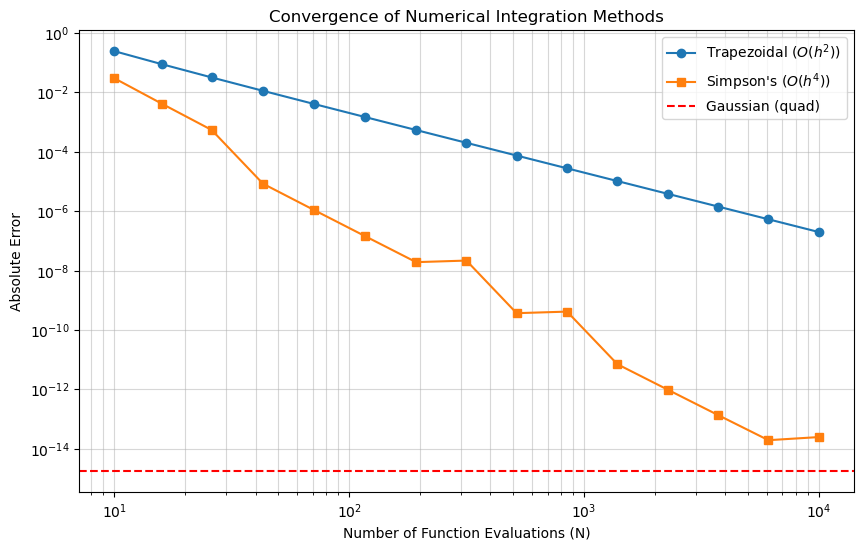

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson


def target_function(x):
    """The function we want to integrate: f(x) = exp(x) * sin(x)"""
    return np.exp(x) * np.sin(x)


def analytical_integral(a, b):
    """The exact analytical solution for comparison."""

    def indefinite_integral(x):
        return 0.5 * np.exp(x) * (np.sin(x) - np.cos(x))

    return indefinite_integral(b) - indefinite_integral(a)

def trapezoidal_rule(f, a, b, n):
    """Manual implementation of the Trapezoidal Rule."""
    x = np.linspace(a, b, n)
    h = (b - a) / (n - 1)
    y = f(x)
    return (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])


def run_comparison():
    a, b = 0, np.pi
    exact = analytical_integral(a, b)

    # Range of 'N' (number of function evaluations) to test
    n_values = np.logspace(1, 4, 15, dtype=int)

    trap_errors = []
    simp_errors = []

    print(f"{'N':>10} | {'Trapezoidal Error':>20} | {'Simpson Error':>20}")
    print("-" * 55)

    for n in n_values:
        # Ensure n is even for Simpson's rule if required by specific implementations
        # though scipy.integrate.simpson handles various cases.
        x = np.linspace(a, b, n)
        y = target_function(x)

        t_val = trapezoidal_rule(target_function, a, b, n)
        s_val = simpson(y, x=x)

        t_err = abs(t_val - exact)
        s_err = abs(s_val - exact)

        trap_errors.append(t_err)
        simp_errors.append(s_err)

        print(f"{n:10d} | {t_err:20.10e} | {s_err:20.10e}")

    # Gaussian Quadrature
    # This usually reaches machine precision with very few points
    gauss_val, _ = quad(target_function, a, b)
    gauss_err = abs(gauss_val - exact)
    print("-" * 55)
    print(f"Gaussian Quadrature Error (SciPy quad): {gauss_err:.10e}")

    # Plotting the Convergence
    plt.figure(figsize=(10, 6))
    plt.loglog(n_values, trap_errors, "o-", label="Trapezoidal ($O(h^2)$)")
    plt.loglog(n_values, simp_errors, "s-", label="Simpson's ($O(h^4)$)")
    plt.axhline(gauss_err, color="r", linestyle="--", label="Gaussian (quad)")

    plt.title("Convergence of Numerical Integration Methods")
    plt.xlabel("Number of Function Evaluations (N)")
    plt.ylabel("Absolute Error")
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    plt.show()


run_comparison()

## 5.Monte Carlo Integration

*Stochastic Integration and Statistical Error Scaling*

### 5.1. The Curse of Dimensionality

In previous sections, we optimized 1D integration. However, physics often happens in high-dimensional phase spaces (e.g., $3N$ positions and $3N$ momenta).

#### 5.1.1 The Grid Scaling Problem

Consider a $d$-dimensional integral over a unit hypercube:


$$I = \int_{0}^{1} \dots \int_{0}^{1} f(x_1, x_2, \dots, x_d) \, dx_1 \dots dx_d$$

If we use a Newton-Cotes method (like Simpson's) and **require $m$ points along each axis** to resolve the function's features, the total number of function evaluations $N$ is:


$$N = m^d$$

If $d=100$ (a system of roughly 33 particles) and we use a very coarse grid of only $m=10$ points per dimension, we require $10^{100}$ evaluations. This exceeds the number of atoms in the observable universe.

#### 5.1.2 Error Scaling in $d$-Dimensions

Recall that in 1D, Simpson's rule error scales as $O(h^4)$, where $h = 1/m$.
In $d$ dimensions, $h = N^{-1/d}$. Therefore, the error for a grid-based method scales as:


$$\text{Error}_{\text{grid}} \approx O(N^{-4/d})$$

As $d \to \infty$, the exponent $-4/d \to 0$. The error essentially stops decreasing regardless of how many points you add. This is the **Curse of Dimensionality**.



### 5.2. Monte Carlo Integration: The Statistical Approach

Instead of a rigid grid, we treat the integral as an expectation value.

#### 5.2.1 The Estimator

By the Mean Value Theorem for integrals, the value of $I$ over a volume $V$ is:


$$I = V \langle f \rangle$$


where $\langle f \rangle$ is the average value of $f$. We can estimate this average by sampling $N$ points $\{\mathbf{x}_i\}$ uniformly at random from the volume $V$:


$$Q_N = \frac{V}{N} \sum_{i=1}^{N} f(\mathbf{x}_i)$$

#### 5.2.2 Proof of Unbiasedness

The expectation value of our estimator $Q_N$ is:


$$E[Q_N] = \frac{V}{N} \sum_{i=1}^{N} E[f(\mathbf{x}_i)] = \frac{V}{N} \cdot N \cdot E[f(\mathbf{x})]] = \frac{V}{N} \cdot N \cdot \frac{1}{V} \int_V f(\mathbf{x}) d\mathbf{x} = I$$


Thus, $Q_N$ is an unbiased estimator of the true integral $I$.



### 5.3. The Magic: Deriving the $1/\sqrt{N}$ Error

The "magic" of Monte Carlo is that its error does not depend on $d$. We prove this using the Variance of the estimator.

#### 5.3.1 Variance Derivation

Assuming the samples $f(\mathbf{x}_i)$ are independent and identically distributed (i.i.d.):


$$\text{Var}(Q_N) = \text{Var}\left( \frac{V}{N} \sum_{i=1}^{N} f_i \right) = \frac{V^2}{N^2} \sum_{i=1}^{N} \text{Var}(f_i)$$

$$\text{Var}(Q_N) = \frac{V^2}{N^2} \cdot N \cdot \sigma_f^2 = \frac{V^2 \sigma_f^2}{N}$$


where $\sigma_f^2$ is the variance of the function $f$ over the volume $V$.

#### 5.3.2 The Standard Error

The standard deviation of our estimate (the "error bar") is:


$$\sigma_{Q_N} = \sqrt{\text{Var}(Q_N)} = \frac{V \sigma_f}{\sqrt{N}}$$

Key Insight: There is no $d$ in the exponent of $N$. Whether you are in 1D or 1,000,000D, doubling the number of points always reduces the error by a factor of $\sqrt{2} \approx 1.41$.



### 5.4 When to use Monte-Carlo integration?

| Feature | Grid Methods (Simpson/Gauss) | Monte Carlo | 
| :--- | :--- | :--- | 
| **Dimension** | Best for $d=1, 2, 3$ | Only viable option for $d > 10$ | 
| **Error Scaling** | $N^{-4/d}$ (Excellent in low $d$) | $N^{-1/2}$ (Same in all $d$) | 
| **Function Type** | Requires smoothness | Can handle discontinuities/fractal boundaries | 
| **Convergence** | Deterministic | Probabilistic (Stochastic) |


**Rule of Thumb**: - If you have a smooth 1D integral, use Gaussian Quadrature.

If you are simulating a galaxy or an N-body system, use Monte Carlo.